<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/%EC%9C%84%ED%97%98%EB%8F%84_%2B_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving accident.xlsx to accident.xlsx
Saving compensation.xlsx to compensation.xlsx


# 학교안전사고 위험도 + SHAP 오류수정 통합본

## 위험도 점수 산출


In [ ]:
import pandas as pd
import numpy as np
import re

TARGET_SHEETS = ['2021', '2022', '2023', '2024', '2025']

# 파일명이 다를 경우 이 두 줄만 수정하세요.
ACCIDENT_FILE = 'accident.xlsx'
COMPENSATION_FILE = 'compensation.xlsx'

def clean_column_name(col):
    """엑셀 열 이름의 줄바꿈·앞뒤 공백·중복 공백을 제거합니다."""
    col = str(col).replace('\n', ' ').replace('\r', ' ').strip()
    col = re.sub(r'\s+', '', col)
    return col

def read_year_sheets(path, target_sheets=TARGET_SHEETS):
    """실제로 존재하는 연도 시트만 읽고 하나의 DataFrame으로 합칩니다."""
    xls = pd.ExcelFile(path)
    available = [str(s).strip() for s in xls.sheet_names]
    selected = [s for s in target_sheets if s in available]

    if not selected:
        # 연도명이 없으면 모든 시트를 사용
        selected = xls.sheet_names
        print(f'주의: {path}에서 2021~2025 시트를 찾지 못해 전체 시트를 사용합니다: {selected}')

    frames = []
    for sheet in selected:
        temp = pd.read_excel(path, sheet_name=sheet)
        temp.columns = [clean_column_name(c) for c in temp.columns]
        temp['원본시트'] = str(sheet)
        frames.append(temp)

    result = pd.concat(frames, ignore_index=True, sort=False)
    result.columns = [clean_column_name(c) for c in result.columns]
    return result

df_accident = read_year_sheets(ACCIDENT_FILE)
df_compensation = read_year_sheets(COMPENSATION_FILE)

print('사고 데이터 크기:', df_accident.shape)
print('보상 데이터 크기:', df_compensation.shape)
print('\n보상 데이터 실제 열 이름:')
print(df_compensation.columns.tolist())


사고 데이터 크기: (528503, 19)
보상 데이터 크기: (865384, 15)

보상 데이터 실제 열 이름:
['구분', '지역', '학교급', '사고자구분', '사고자학년', '사고자성별', '사고연월', '사고발생시각', '사고요일', '사고시간', '사고장소', '사고부위', '사고형태', '사고당시활동', '원본시트']


In [ ]:
import pandas as pd
import re

# ---------------------------------------------------------
# 보상액 열 자동 탐색 및 총보상액 계산
# ---------------------------------------------------------

def normalize_text(value):
    return re.sub(r'[^가-힣a-zA-Z0-9]', '', str(value)).lower()

# 데이터마다 명칭이 달라질 수 있어 여러 후보를 허용합니다.
COMPENSATION_ALIASES = {
    '요양급여': ['요양급여', '요양비', '치료비', '의료비'],
    '장해급여': ['장해급여', '장애급여', '장해보상'],
    '간병급여': ['간병급여', '간병비'],
    '유족급여': ['유족급여', '유족보상'],
    '장례비': ['장례비', '장의비'],
    '위로금': ['위로금', '위문금'],
    '보전비용': ['보전비용', '보전비', '기타비용', '기타급여']
}
TOTAL_ALIASES = [
    '총보상액', '보상액합계', '총지급액', '지급액합계',
    '총급여액', '보상금액', '지급금액', '결정보상액'
]

def find_column_by_alias(columns, aliases):
    norm_map = {normalize_text(c): c for c in columns}
    # 정확 일치 우선
    for alias in aliases:
        key = normalize_text(alias)
        if key in norm_map:
            return norm_map[key]
    # 부분 일치 보조
    for alias in aliases:
        key = normalize_text(alias)
        for norm_col, original in norm_map.items():
            if key and (key in norm_col or norm_col in key):
                return original
    return None

# NOTE: df_compensation이 아닌 df_accident에 보상액 정보가 있으므로 df_accident를 사용합니다.
# 1) 이미 총액 열이 있으면 우선 사용
existing_total_col = find_column_by_alias(df_accident.columns, TOTAL_ALIASES)

if existing_total_col is not None:
    df_accident['총보상액'] = pd.to_numeric(
        df_accident[existing_total_col].astype(str)
        .str.replace(',', '', regex=False)
        .str.replace('원', '', regex=False)
        .str.strip(),
        errors='coerce'
    ).fillna(0)
    used_compensation_cols = [existing_total_col]
    print(f'총보상액 열로 사용: {existing_total_col}')
else:
    # 2) 개별 급여 열을 자동 탐색하여 합산
    found = {}
    for standard_name, aliases in COMPENSATION_ALIASES.items():
        col = find_column_by_alias(df_accident.columns, aliases)
        if col is not None:
            found[standard_name] = col

    used_compensation_cols = list(dict.fromkeys(found.values()))

    if not used_compensation_cols:
        raise KeyError(
            '보상액 관련 열을 자동으로 찾지 못했습니다.\n'
            f'현재 열 이름: {df_accident.columns.tolist()}\n'
            '총보상액·총지급액·보상금액 또는 요양급여·장해급여 등의 열 이름을 확인하세요.'
        )

    numeric_comp = pd.DataFrame(index=df_accident.index)
    for col in used_compensation_cols:
        numeric_comp[col] = pd.to_numeric(
            df_accident[col].astype(str)
            .str.replace(',', '', regex=False)
            .str.replace('원', '', regex=False)
            .str.strip(),
            errors='coerce'
        ).fillna(0)

    df_accident['총보상액'] = numeric_comp.sum(axis=1)
    print('총보상액 합산에 사용한 열:', used_compensation_cols)

# 사고형태 열 존재 여부 확인
required_base = ['학교급', '사고장소', '사고형태']
missing_base = [c for c in required_base if c not in df_accident.columns]
if missing_base:
    raise KeyError(
        f'분석에 필요한 열이 없습니다: {missing_base}\n'
        f'현재 열 이름: {df_accident.columns.tolist()}'
    )

severity_df = (
    df_accident.groupby('사고형태', dropna=False)['총보상액']
    .agg(['sum', 'mean', 'count'])
    .reset_index()
    .rename(columns={
        'sum': 'Total_Compensation',
        'mean': 'Average_Compensation',
        'count': 'Number_of_Cases'
    })
)

display(severity_df.head())


총보상액 합산에 사용한 열: ['요양급여', '장해급여', '간병급여', '유족급여', '장례비', '위로금', '보전비용']


,사고형태,Total_Compensation,Average_Compensation,Number_of_Cases
0,1미터 미만의 높이에서 떨어짐,12874629000,1.086558e+06,11849
1,1미터 이상의 높이에서 떨어짐,2876162000,9.476646e+05,3035
2,감전,32559000,3.130673e+05,104
3,고온의 물체·물질 접촉·흡입·섭취,1957949000,4.420747e+05,4429
4,고정된 물체와의 부딪힘,35512081000,3.464357e+05,102507


## 학생수 기반 위험도 산출

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

population = {
    '연도': ['2021', '2022', '2023', '2024', '2025'] * 3,
    '학교급': ['초등학교']*5 + ['중학교']*5 + ['고등학교']*5,
    '학생수_천명': [
        2672, 2664, 2604, 2495, 2345,  # 초등학교
        1351, 1348, 1327, 1333, 1370,  # 중학교
        1300, 1262, 1278, 1304, 1299   # 고등학교
    ]
}

df_pop = pd.DataFrame(population)

# 1. 5년(2021~2025) 평균 학생수 산출 (학교급별)
avg_pop = df_pop.groupby('학교급')['학생수_천명'].mean().reset_index()
avg_pop.rename(columns={'학생수_천명': '평균학생수_천명'}, inplace=True)

# 2. 기존 그룹별 집계 시, 빈도(사고 건수)와 심각성(평균 보상액) 산출
group_cols = ['학교급', '사고장소', '사고형태']
risk_df = (
    df_accident.groupby(group_cols, dropna=False)
    .agg(
        사고건수=('총보상액', 'size'),
        평균보상액=('총보상액', 'mean')
    )
    .reset_index()
)

# 3. 평균 학생수 결합 및 '빈도율(1,000명당 사고건수)' 계산
risk_df = pd.merge(risk_df, avg_pop, on='학교급', how='left')
risk_df['빈도율'] = risk_df['사고건수'] / risk_df['평균학생수_천명']

# 4. 로그 변환 (이상치 및 편향 보정)
risk_df['log_빈도율'] = np.log1p(risk_df['빈도율'])
risk_df['log_평균보상액'] = np.log1p(risk_df['평균보상액'])

# 5. 1-10점으로 정규화 (Min-Max Scaling)
scaler = MinMaxScaler(feature_range=(0, 10))
risk_df[['빈도_점수', '심도_점수']] = scaler.fit_transform(risk_df[['log_빈도율', 'log_평균보상액']])

# 6. 최종 위험도 점수 산출 (빈도 40%, 심각성 60% 가중치)
w_freq, w_sev = 0.4, 0.6
risk_df['위험도_점수'] = ((risk_df['빈도_점수'] * w_freq) + (risk_df['심도_점수'] * w_sev)).round(2)


In [ ]:
risk_df.head(10)

,학교급,사고장소,사고형태,사고건수,평균보상액,평균학생수_천명,빈도율,log_빈도율,log_평균보상액,빈도_점수,심도_점수,위험도_점수
0,고등학교,가정,그밖의 손상 사고,1,1.680000e+05,1288.6,0.000776,0.000776,12.031725,0.001405,3.860904,2.32
1,고등학교,가정,넘어짐,9,6.226667e+05,1288.6,0.006984,0.006960,13.341768,0.024003,4.848212,2.92
2,고등학교,가정,움직이는 물체와의 부딪힘,1,2.200000e+05,1288.6,0.000776,0.000776,12.301387,0.001405,4.064134,2.44
3,고등학교,가정,이동 중 충격을 가함,1,4.180000e+05,1288.6,0.000776,0.000776,12.943239,0.001405,4.547862,2.73
4,고등학교,강·바다·하천,1미터 미만의 높이에서 떨어짐,3,7.973333e+05,1288.6,0.002328,0.002325,13.589029,0.007068,5.034559,3.02
5,고등학교,강·바다·하천,1미터 이상의 높이에서 떨어짐,1,6.990000e+05,1288.6,0.000776,0.000776,13.457407,0.001405,4.935363,2.96
6,고등학교,강·바다·하천,고정된 물체와의 부딪힘,10,2.509000e+05,1288.6,0.007760,0.007730,12.432814,0.026818,4.163182,2.51
7,고등학교,강·바다·하천,그밖의 손상 사고,6,7.608333e+05,1288.6,0.004656,0.004645,13.542171,0.015545,4.999245,3.01
8,고등학교,강·바다·하천,"긁힘, 찔림",6,7.966667e+04,1288.6,0.004656,0.004645,11.285619,0.015545,3.298604,1.99
9,고등학교,강·바다·하천,넘어짐,12,7.905583e+06,1288.6,0.009312,0.009269,15.883080,0.032441,6.763460,4.07


In [ ]:
top10_risk = risk_df.sort_values(by='위험도_점수', ascending=False).head(10)

top10_risk

,학교급,사고장소,사고형태,사고건수,평균보상액,평균학생수_천명,빈도율,log_빈도율,log_평균보상액,빈도_점수,심도_점수,위험도_점수
1869,중학교,운동장,넘어짐,19436,5.707578e+05,1345.8,14.441968,2.737089,13.254722,10.000000,4.782610,6.87
486,고등학교,운동장,넘어짐,12161,1.168464e+06,1288.6,9.437374,2.345393,13.971201,8.568728,5.322581,6.62
1877,중학교,운동장,움직이는 물체와의 부딪힘,13702,2.509304e+05,1345.8,10.181305,2.414243,12.432935,8.820309,4.163274,6.03
2190,초등학교,교통구역(스쿨존 내)-차도,교통사고,1,5.794510e+08,2556.0,0.000391,0.000391,20.177592,0.000000,10.000000,6.00
1876,중학교,운동장,스포츠 활동 중 충격을 가함,11595,3.772818e+05,1345.8,8.615693,2.263396,12.840750,8.269109,4.470622,5.99
1419,중학교,강당(체육관),움직이는 물체와의 부딪힘,14393,1.903830e+05,1345.8,10.694754,2.459140,12.156798,8.984365,3.955165,5.97
1863,중학교,운동장,고정된 물체와의 부딪힘,11507,3.533198e+05,1345.8,8.550305,2.256573,12.775132,8.244176,4.421169,5.95
1418,중학교,강당(체육관),스포츠 활동 중 충격을 가함,11468,3.481589e+05,1345.8,8.521326,2.253534,12.760417,8.233072,4.410079,5.94
1411,중학교,강당(체육관),넘어짐,10283,4.592508e+05,1345.8,7.640808,2.156496,13.037354,7.878491,4.618792,5.92
31,고등학교,강당(체육관),스포츠 활동 중 충격을 가함,8798,5.963493e+05,1288.6,6.827565,2.057651,13.298583,7.517309,4.815666,5.90


- "중학생/고등학생의 운동장에서 넘어짐" 사고와, "중학생의 운동장에서 움직이는 물체와의 부딪힘" 사고 등이 높은 위험도 점수를 보임

## 위험등급 타깃 지정

In [ ]:
# 1. 6단계 타겟 생성
quantiles = [0, 0.40, 0.70, 0.90, 0.95, 0.99, 1.0]
labels = ['6등급_저위험', '5등급_일반위험', '4등급_중점관리', '3등급_고위험', '2등급_심각위험', '1등급_초고위험']
risk_df['정밀_위험등급'] = pd.qcut(risk_df['위험도_점수'], q=quantiles, labels=labels)

# 2. 4사분면 매트릭스 타겟 생성 (상위 5% 기준)
freq_threshold = risk_df['빈도_점수'].quantile(0.95)
sev_threshold = risk_df['심도_점수'].quantile(0.95)

def get_matrix_target(row):
    if row['빈도_점수'] >= freq_threshold and row['심도_점수'] >= sev_threshold:
        return 'A군_즉각개입 (고빈도+고심도)'
    elif row['빈도_점수'] < freq_threshold and row['심도_점수'] >= sev_threshold:
        return 'B군_인프라강화 (저빈도+고심도)'
    elif row['빈도_점수'] >= freq_threshold and row['심도_점수'] < sev_threshold:
        return 'C군_교육강화 (고빈도+저심도)'
    else:
        return 'D군_모니터링 (저빈도+저심도)'

risk_df['매트릭스_타겟'] = risk_df.apply(get_matrix_target, axis=1)

# 3. 원본 데이터에 매핑
df_model_ready = pd.merge(
    df_compensation,
    risk_df[group_cols + ['위험도_점수', '정밀_위험등급', '매트릭스_타겟']],
    on=group_cols,
    how='left'
)

In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!pip install koreanize-matplotlib

import koreanize_matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (9,007 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direc

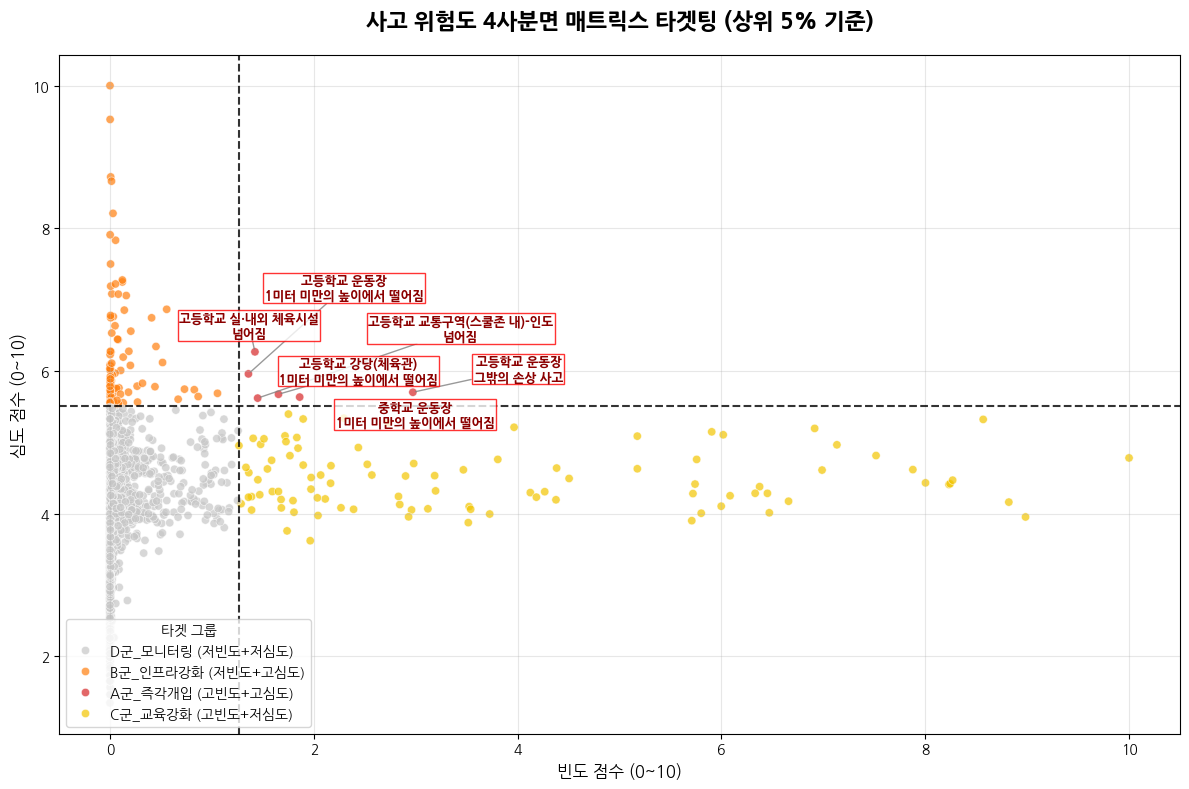

In [ ]:
!pip install adjustText

import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

plt.figure(figsize=(12, 8))

# 4사분면 산점도 그리기
custom_palette = {
    'A군_즉각개입 (고빈도+고심도)': '#d62728',  # Red
    'B군_인프라강화 (저빈도+고심도)': '#ff7f0e',  # Orange
    'C군_교육강화 (고빈도+저심도)': '#f3c500',  # Yellow
    'D군_모니터링 (저빈도+저심도)': '#c7c7c7'   # Grey
}

sns.scatterplot(
    data=risk_df,
    x='빈도_점수',
    y='심도_점수',
    hue='매트릭스_타겟',
    palette=custom_palette,
    alpha=0.7
)

# 기준선 (Threshold) 긋기
# 설정한 상위 5% 기준 (freq_threshold, sev_threshold)
plt.axvline(x=freq_threshold, color='black', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axhline(y=sev_threshold, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

target_a_group = risk_df[risk_df['매트릭스_타겟'] == 'A군_즉각개입 (고빈도+고심도)']

texts = []

for idx, row in target_a_group.iterrows():
    label_text = f"{row['학교급']} {row['사고장소']}\n{row['사고형태']}"

    txt = plt.text(
        x=row['빈도_점수'],
        y=row['심도_점수'],
        s=label_text,
        fontsize=9,
        color='darkred',
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='red', pad=1)
    )
    texts.append(txt)

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=1, alpha=0.8))

plt.title('사고 위험도 4사분면 매트릭스 타겟팅 (상위 5% 기준)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('빈도 점수 (0~10)', fontsize=12)
plt.ylabel('심도 점수 (0~10)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title='타겟 그룹', loc='lower left')

plt.tight_layout()
plt.show()

- 고등학교: 실내외 체육시설 넘어짐, 운동장 1미터 미만의 높이에서 떨어짐, 교통구역(스쿨존 내) 인도 넘어짐, 강당(체육관) 1미터 미만의 높이에서 떨어짐, 운동장 그밖의 손상 사고
- 중학교: 운동장 1미터 미만의 높이에서 떨어짐
- 위와 같은 사고들은 고빈도+고심도 그룹으로, 즉각개입이 필요하다고 판단됨

# 3. 사고별 위험등급 예측

### 3.1 K-Means 클러스터링으로 위험등급 분류

'위험도_점수'를 활용하여 K-Means 클러스터링을 수행하고, Elbow Method를 통해 최적의 군집(K) 개수를 결정합니다. 이후 군집별 위험도 점수를 기반으로 '고위험', '중위험', '저위험' 등급을 부여합니다.

In [ ]:
# 1. 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib # 한글 깨짐 방지

In [ ]:
# 3. 'risk_score' 변수 추출 및 K-Means 입력용 데이터 변환 (2차원 배열 형태로)
X = risk_df[['위험도_점수']].values

### 3.2 Elbow Method를 활용한 최적의 K 찾기

WCSS(Within-Cluster Sum of Square) 값을 계산하여 K(군집 개수)에 따른 변화를 시각화합니다. WCSS가 급격히 줄어드는 지점이 최적의 K 값으로 고려될 수 있습니다.

'위험도_점수'에 NaN 값을 포함하여 972개의 행이 제거되었습니다.


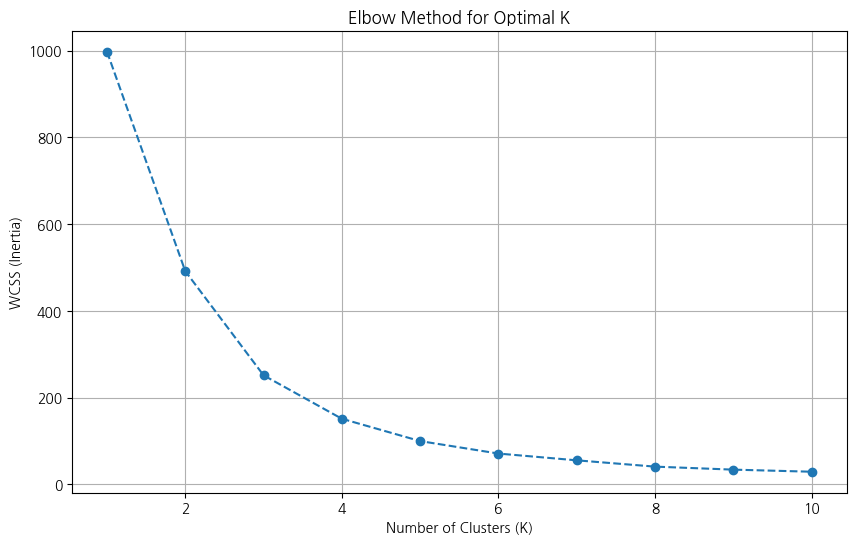

In [ ]:
# 4. Elbow Method(엘보우 방법)를 활용해 최적의 K(1부터 10까지)를 찾기 위한 WCSS(Inertia) 계산 및 시각화 코드

# KMeans 모델은 NaN 값을 허용하지 않으므로, '위험도_점수' 컬럼에 NaN이 있는 행은 제거합니다.
# 이 작업은 원본 'risk_df'에 영구적으로 반영되어 이후 K-Means 모델 학습 시에도 사용될 것입니다.
original_rows = len(risk_df)
risk_df.dropna(subset=['위험도_점수'], inplace=True)
dropped_rows = original_rows - len(risk_df)
if dropped_rows > 0:
    print(f"'위험도_점수'에 NaN 값을 포함하여 {dropped_rows}개의 행이 제거되었습니다.")

# 업데이트된 risk_df에서 K-Means 입력용 데이터 X를 다시 추출합니다.
X = risk_df[['위험도_점수']].values


wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto') # n_init='auto' for KMeans
    kmeans.fit(X) # 이제 X는 NaN이 없는 깨끗한 데이터입니다.
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

### 3.3 K-Means 모델 학습 및 위험 등급 매핑

Elbow Method 결과를 바탕으로 최적의 K 값을 선택하여 K-Means 모델을 학습시키고, 각 군집의 평균 위험도 점수에 따라 '고위험', '중위험', '저위험' 등급을 부여합니다.

In [ ]:
# 5. 사용자가 시각화 확인 후 K 값을 지정하면(예: K=3), 해당 K 값으로 최종 K-Means 모델을 학습시키는 코드
# Elbow plot에서 K=3이 적절해 보이므로 K=3으로 설정합니다.
k = 3  # 사용자가 지정할 K 값

kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
risk_df['cluster'] = kmeans.fit_predict(X)

# 6. 군집(Cluster) 번호별 'risk_score'의 평균을 계산하여,
#    평균 점수가 높은 순서대로 '고위험', '중위험', '저위험' (또는 1등급, 2등급, 3등급)으로 등급을 자동 매핑(Mapping)하는 코드
cluster_means = risk_df.groupby('cluster')['위험도_점수'].mean().sort_values(ascending=False)

# 등급 정의 (예: 1등급_초고위험, 2등급_심각위험, 3등급_고위험)
# 여기서는 간단히 K에 따라 등급을 나눕니다.
# 예시로 K=3일 경우 '고위험', '중위험', '저위험'으로 매핑
risk_labels = [f'{i+1}등급' for i in range(k)]
risk_grade_mapping = dict(zip(cluster_means.index, risk_labels))

# cluster_means가 정렬된 순서대로 라벨 매핑
sorted_clusters = cluster_means.index.tolist()
risk_grade_map = {}
# 예시로 3개 등급을 가정하여 '1등급_초고위험', '2등급_심각위험', '3등급_고위험' 부여
if k == 3:
    risk_grade_map[sorted_clusters[0]] = '1등급_초고위험'
    risk_grade_map[sorted_clusters[1]] = '2등급_심각위험'
    risk_grade_map[sorted_clusters[2]] = '3등급_고위험'
elif k == 4:
    risk_grade_map[sorted_clusters[0]] = '1등급_초고위험'
    risk_grade_map[sorted_clusters[1]] = '2등급_심각위험'
    risk_grade_map[sorted_clusters[2]] = '3등급_고위험'
    risk_grade_map[sorted_clusters[3]] = '4등급_저위험'
# 필요에 따라 다른 K 값에 대한 매핑 추가 가능

risk_df['위험등급'] = risk_df['cluster'].map(risk_grade_map)

# 7. 기존 데이터프레임 `risk_df`에 최종 등급이 부여된 `'위험등급'` 컬럼을 추가하고, 상위 5개 행을 확인하는 코드
display(risk_df.head())

,학교급,사고장소,사고형태,사고건수,평균보상액,평균학생수_천명,빈도율,log_빈도율,log_평균보상액,빈도_점수,심도_점수,위험도_점수,정밀_위험등급,매트릭스_타겟,cluster,위험등급
0,고등학교,가정,그밖의 손상 사고,1,168000.000000,1288.6,0.000776,0.000776,12.031725,0.001405,3.860904,2.32,6등급_저위험,D군_모니터링 (저빈도+저심도),0,3등급_고위험
1,고등학교,가정,넘어짐,9,622666.666667,1288.6,0.006984,0.006960,13.341768,0.024003,4.848212,2.92,4등급_중점관리,D군_모니터링 (저빈도+저심도),1,2등급_심각위험
2,고등학교,가정,움직이는 물체와의 부딪힘,1,220000.000000,1288.6,0.000776,0.000776,12.301387,0.001405,4.064134,2.44,5등급_일반위험,D군_모니터링 (저빈도+저심도),0,3등급_고위험
3,고등학교,가정,이동 중 충격을 가함,1,418000.000000,1288.6,0.000776,0.000776,12.943239,0.001405,4.547862,2.73,5등급_일반위험,D군_모니터링 (저빈도+저심도),1,2등급_심각위험
4,고등학교,강·바다·하천,1미터 미만의 높이에서 떨어짐,3,797333.333333,1288.6,0.002328,0.002325,13.589029,0.007068,5.034559,3.02,4등급_중점관리,D군_모니터링 (저빈도+저심도),1,2등급_심각위험


### 3.4 머신러닝 분류 모델 구축 및 평가

K-Means 클러스터링으로 분류된 '위험등급'을 타겟 변수로 설정하고, '학교급', '사고장소', '사고형태'와 같은 학교 고유의 특성을 입력 변수로 활용하여 분류 모델을 구축합니다.

**데이터 누수 방지(Data Leakage Prevention)를 위해 `위험도_점수` 및 이를 구성하는 `사고건수`, `평균보상액`, `빈도_점수`, `심도_점수` 등은 입력 변수에서 제외합니다.**

In [ ]:
# 1. 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

import xgboost as xgb
import lightgbm as lgb

!pip install catboost
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib # 한글 깨짐 방지

# K-Means 클러스터링 결과가 담긴 risk_df를 사용합니다.
# 이미 한글 폰트 설정은 완료되어 있다고 가정합니다.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [ ]:
# 2. 데이터 전처리 및 데이터셋 분할 (Train / Test = 8:2)

# 입력 변수(X)와 타겟 변수(Y) 정의
# '위험도_점수'와 'cluster' (위험등급 생성에 직접 사용된 컬럼), '정밀_위험등급' (다른 방식의 등급), '매트릭스_타겟'을 제외합니다.
# '사고건수', '평균보상액', '평균학생수_천명', '빈도율', 'log_빈도율', 'log_평균보상액', '빈도_점수', '심도_점수' 또한 위험도 점수 산출에 사용되었으므로 제외합니다.

features = ['학교급', '사고장소', '사고형태']
X = risk_df[features].copy()
Y = risk_df['위험등급'].copy()

# 타겟 변수('위험등급')를 모델 학습이 가능하도록 수치형으로 인코딩
# '1등급_초고위험': 2, '2등급_심각위험': 1, '3등급_고위험': 0 (더 높은 등급에 더 높은 숫자 부여)
y_mapping = {'1등급_초고위험': 2, '2등급_심각위험': 1, '3등급_고위험': 0}
Y_encoded = Y.map(y_mapping)

# 범주형 독립 변수에 라벨 인코딩 적용
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# 데이터셋 분할 (Train / Test = 8:2)
X_train, X_test, y_train, y_test = train_test_split(X, Y_encoded, test_size=0.2, random_state=42, stratify=Y_encoded)

### 3. 모델 학습 및 평가

XGBoost, LightGBM, CatBoost 세 가지 분류 모델을 학습시키고, Test 데이터에 대한 Accuracy, Macro F1-Score, Confusion Matrix를 통해 성능을 비교합니다.


--- Training XGBoost Model ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:12:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost Model Evaluation ===
Accuracy: 0.6897
Macro F1-Score: 0.5652

Classification Report:
              precision    recall  f1-score   support

     3등급_고위험       0.68      0.67      0.67       170
    2등급_심각위험       0.71      0.74      0.72       219
    1등급_초고위험       0.40      0.24      0.30        17

    accuracy                           0.69       406
   macro avg       0.60      0.55      0.57       406
weighted avg       0.68      0.69      0.69       406


--- Training LightGBM Model ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000266 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 79
[LightGBM] [Info] Number of data points in the train set: 1622, number of used features: 3
[LightGBM] [Info] Start training from score -0.872268
[LightGBM] [Info] Start training from score -0.618335
[LightGBM] [Info] Start training from score -3.142920

=== LightGBM Model Evaluation ===
Accura

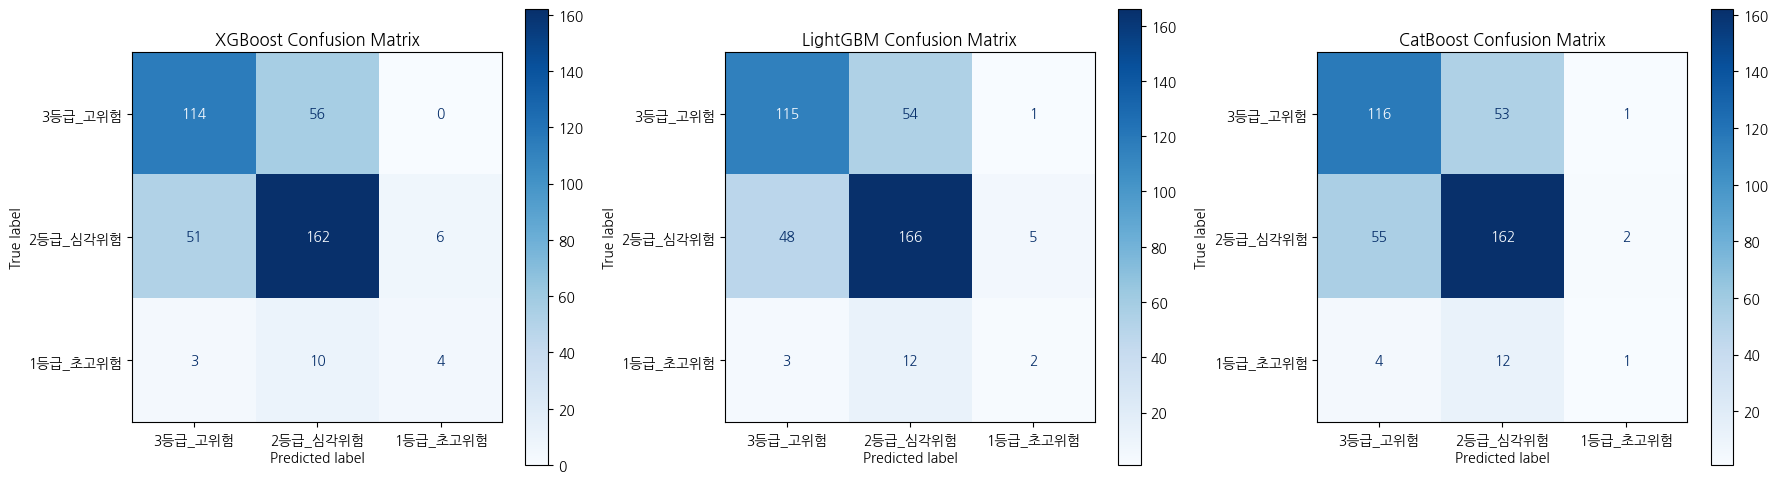

In [ ]:
results = {}

def evaluate_model(model, X_test, y_test, model_name, ax=None):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\n=== {model_name} Model Evaluation ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['3등급_고위험', '2등급_심각위험', '1등급_초고위험'])) # 등급 순서에 맞게 target_names 지정

    # Confusion Matrix 시각화
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['3등급_고위험', '2등급_심각위험', '1등급_초고위험'], cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'{model_name} Confusion Matrix')

    return accuracy, f1

# Confusion Matrix를 한 화면에 그리기 위한 설정
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1행 3열 서브플롯 생성

# XGBoost 분류기
print("\n--- Training XGBoost Model ---")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
results['XGBoost'] = evaluate_model(xgb_model, X_test, y_test, 'XGBoost', ax=axes[0])

# LightGBM 분류기
print("\n--- Training LightGBM Model ---")
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
results['LightGBM'] = evaluate_model(lgb_model, X_test, y_test, 'LightGBM', ax=axes[1])

# CatBoost 분류기
print("\n--- Training CatBoost Model ---")
# CatBoost는 기본적으로 범주형 특성을 잘 처리하지만, 여기서는 Label Encoding된 데이터를 사용하므로 모든 특성을 수치형으로 간주합니다.
cat_model = CatBoostClassifier(random_state=42, verbose=0, iterations=100) # verbose=0으로 출력 억제
cat_model.fit(X_train, y_train)
results['CatBoost'] = evaluate_model(cat_model, X_test, y_test, 'CatBoost', ax=axes[2])

plt.tight_layout()
plt.show()

### 4. 모델 성능 시각화

세 가지 모델의 Macro F1-Score를 바 차트(Bar Chart)로 시각화하여 성능을 직관적으로 비교합니다.

/tmp/ipykernel_1417/1226198733.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f1_scores, palette='viridis')


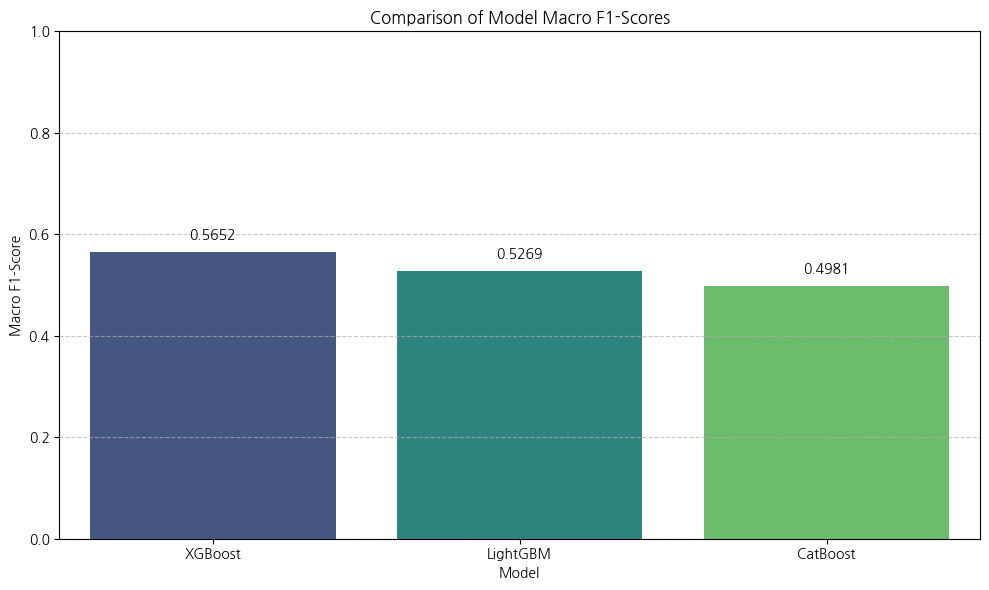

In [ ]:
# 모델별 F1-Score 추출
model_names = list(results.keys())
f1_scores = [score[1] for score in results.values()]

# F1-Score 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=f1_scores, palette='viridis')
plt.title('Comparison of Model Macro F1-Scores')
plt.xlabel('Model')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0) # F1-Score는 0에서 1 사이 값
for index, value in enumerate(f1_scores):
    plt.text(index, value + 0.02, f'{value:.4f}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Class Weight를 적용한 모델 학습 및 평가

클래스 불균형 문제를 완화하기 위해 `Class Weight`를 계산하여 각 모델에 적용한 후 다시 학습하고 평가합니다. 소수 클래스에 더 높은 가중치를 부여함으로써 모델이 해당 클래스의 샘플을 더 중요하게 학습하도록 유도합니다.

Calculated Class Weights:
{np.int64(0): np.float64(0.7974434611602753), np.int64(1): np.float64(0.6186117467581999), np.int64(2): np.float64(7.723809523809524)}

--- Training XGBoost Model (Weighted) ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:12:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost (Weighted) Model Evaluation ===
Accuracy: 0.6823
Macro F1-Score: 0.5765

Classification Report:
              precision    recall  f1-score   support

     3등급_고위험       0.66      0.72      0.69       170
    2등급_심각위험       0.73      0.68      0.70       219
    1등급_초고위험       0.32      0.35      0.33        17

    accuracy                           0.68       406
   macro avg       0.57      0.58      0.58       406
weighted avg       0.69      0.68      0.68       406


--- Training LightGBM Model (Weighted) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000125 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 79
[LightGBM] [Info] Number of data points in the train set: 1622, number of used features: 3
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612

=== LightGBM (Weig

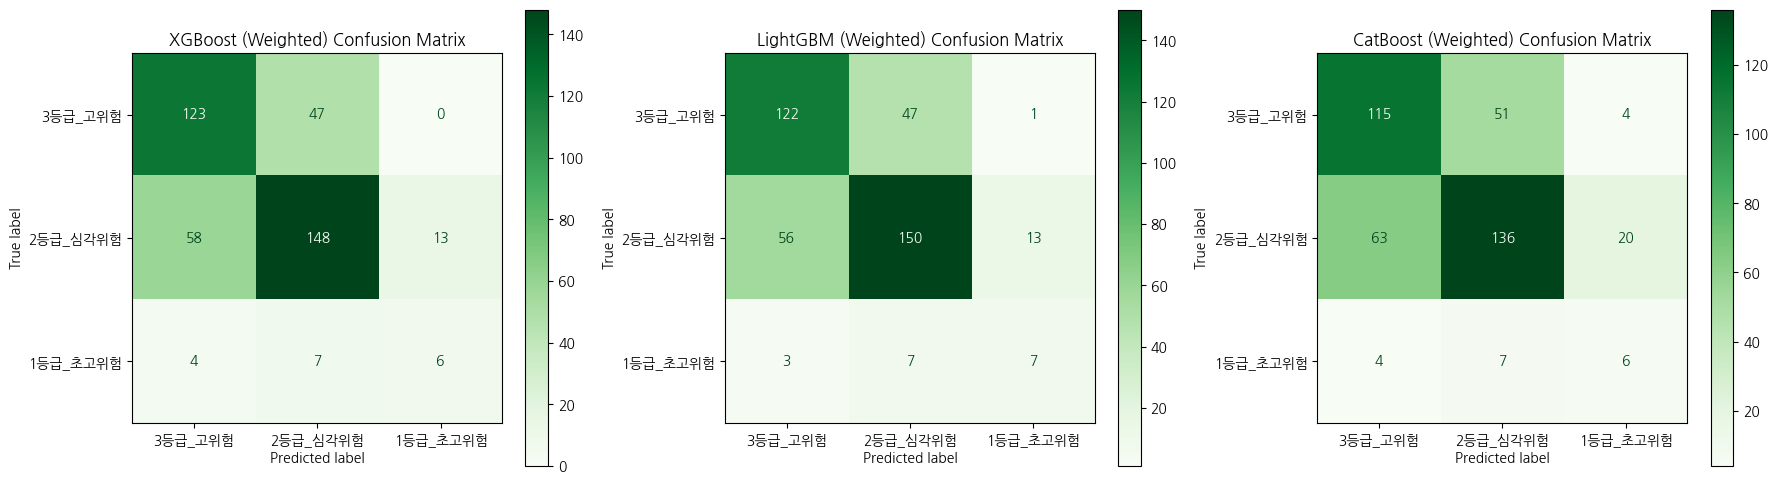

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# 클래스 레이블과 y_train 데이터에서 클래스 가중치를 계산합니다.
# 'balanced' 모드는 클래스 빈도에 반비례하여 가중치를 자동으로 조정합니다.
classes = np.unique(y_train)
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# 계산된 클래스 가중치를 딕셔너리 형태로 변환합니다.
# {클래스 레이블: 가중치}
class_weights_dict = dict(zip(classes, class_weights))

print("Calculated Class Weights:")
print(class_weights_dict)

# 각 샘플에 해당하는 가중치 배열을 생성합니다.
# y_train의 각 요소에 해당하는 class_weights_dict의 값을 매핑합니다.
# 이 sample_weights는 XGBoost에 사용됩니다.
sample_weights = np.array([class_weights_dict[label] for label in y_train])

weighted_results = {}

def evaluate_weighted_model(model, X_test, y_test, model_name, ax=None):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\n=== {model_name} (Weighted) Model Evaluation ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['3등급_고위험', '2등급_심각위험', '1등급_초고위험']))

    # Confusion Matrix 시각화
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['3등급_고위험', '2등급_심각위험', '1등급_초고위험'], cmap=plt.cm.Greens, ax=ax)
    ax.set_title(f'{model_name} (Weighted) Confusion Matrix')

    return accuracy, f1


# Confusion Matrix를 한 화면에 그리기 위한 설정 (Weighted Models)
fig_w, axes_w = plt.subplots(1, 3, figsize=(18, 5))

# XGBoost 분류기 (Weighted)
print("\n--- Training XGBoost Model (Weighted) ---")
xgb_model_w = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model_w.fit(X_train, y_train, sample_weight=sample_weights)
weighted_results['XGBoost_Weighted'] = evaluate_weighted_model(xgb_model_w, X_test, y_test, 'XGBoost', ax=axes_w[0])

# LightGBM 분류기 (Weighted)
print("\n--- Training LightGBM Model (Weighted) ---")
lgb_model_w = lgb.LGBMClassifier(random_state=42, class_weight=class_weights_dict)
lgb_model_w.fit(X_train, y_train)
weighted_results['LightGBM_Weighted'] = evaluate_weighted_model(lgb_model_w, X_test, y_test, 'LightGBM', ax=axes_w[1])

# CatBoost 분류기 (Weighted)
print("\n--- Training CatBoost Model (Weighted) ---")
cat_model_w = CatBoostClassifier(random_state=42, verbose=0, iterations=100, class_weights=list(class_weights_dict.values()))
cat_model_w.fit(X_train, y_train)
weighted_results['CatBoost_Weighted'] = evaluate_weighted_model(cat_model_w, X_test, y_test, 'CatBoost', ax=axes_w[2])

plt.tight_layout()
plt.show()

### 원본 모델과 Class Weight 적용 모델의 Macro F1-Score 비교


--- Macro F1-Score Comparison ---


,XGBoost,LightGBM,CatBoost
Original,0.565228,0.526889,0.498053
Weighted,0.576460,0.590933,0.522441


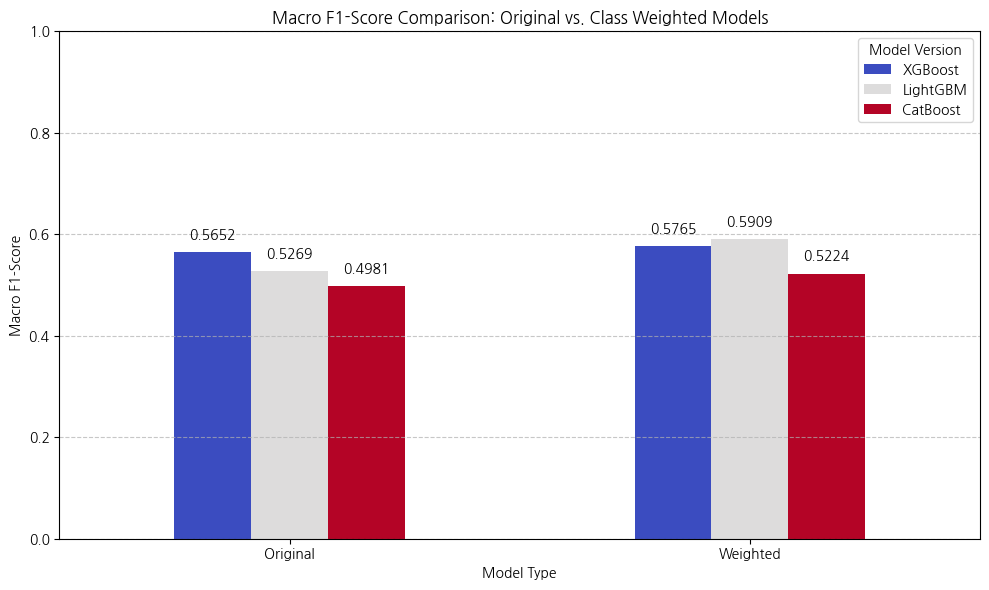

In [ ]:
# 원본 모델의 F1-Score 추출
original_f1_scores = {name: score[1] for name, score in results.items()}

# 가중치 적용 모델의 F1-Score 추출
weighted_f1_scores = {name.replace('_Weighted', ''): score[1] for name, score in weighted_results.items()}

# 데이터프레임으로 변환하여 비교 용이하게
comparison_df = pd.DataFrame({
    'Original': original_f1_scores,
    'Weighted': weighted_f1_scores
}).T # Transpose for easier plotting

print("\n--- Macro F1-Score Comparison ---")
display(comparison_df)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind='bar', ax=ax, rot=0, cmap='coolwarm')
plt.title('Macro F1-Score Comparison: Original vs. Class Weighted Models')
plt.xlabel('Model Type')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0)
plt.legend(title='Model Version')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 각 막대 위에 값 표시
for container in ax.containers:
    for i, v in enumerate(container.patches):
        ax.text(v.get_x() + v.get_width() / 2, v.get_height() + 0.02,
                f'{v.get_height():.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### LightGBM 하이퍼파라미터 튜닝 (Optuna 사용)

Optuna 라이브러리를 사용하여 LightGBM 모델의 하이퍼파라미터를 최적화합니다. Macro F1-Score를 최대화하는 방향으로 튜닝을 진행할 것입니다.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 17.7 MB/s eta 0:00:00


[I 2026-07-19 15:13:15,628] A new study created in memory with name: no-name-b950f203-b1a1-4d4d-ab18-11f06f2ee311



--- Starting Optuna Hyperparameter Tuning for LightGBM ---


  0%|          | 0/50 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

AttributeError: 'NoneType' object has no attribute 'set_title'

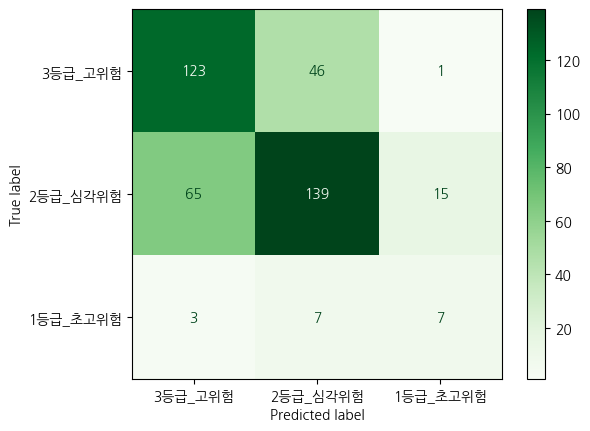

In [ ]:
!pip install optuna

# 필요한 라이브러리 임포트
import optuna
from sklearn.model_selection import StratifiedKFold

# Optuna Objective 함수 정의
def objective(trial):
    # LightGBM 하이퍼파라미터 제안
    params = {
        'objective': 'multiclass',
        'num_class': len(np.unique(y_train)),
        'metric': 'multi_logloss',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': class_weights_dict, # 클래스 가중치 적용
    }

    # 교차 검증을 위한 StratifiedKFold 설정
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_train_fold, y_train_fold)
        y_pred_val = model.predict(X_val_fold)
        f1 = f1_score(y_val_fold, y_pred_val, average='macro')
        f1_scores.append(f1)

    return np.mean(f1_scores)

# Optuna Study 생성 및 최적화
print("\n--- Starting Optuna Hyperparameter Tuning for LightGBM ---")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n--- Optuna Tuning Results ---")
print(f"Best trial: {study.best_trial.value:.4f}")
print("Best parameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# 최적의 하이퍼파라미터로 LightGBM 모델 재학습
best_lgbm_params = study.best_trial.params
best_lgbm_params['class_weight'] = class_weights_dict # 클래스 가중치 재적용

print("\n--- Training LightGBM Model with Best Hyperparameters (Weighted) ---")
tuned_lgbm_model = lgb.LGBMClassifier(**best_lgbm_params, random_state=42, n_jobs=-1)
tuned_lgbm_model.fit(X_train, y_train)

# 튜닝된 모델 평가
weighted_results['LightGBM_Tuned'] = evaluate_weighted_model(tuned_lgbm_model, X_test, y_test, 'LightGBM_Tuned')

# F1-Score 비교 업데이트
original_f1_scores['LightGBM'] = results['LightGBM'][1] # 원본 LightGBM F1-Score
weighted_f1_scores['LightGBM'] = weighted_results['LightGBM_Weighted'][1] # 가중치 적용 LightGBM F1-Score
weighted_f1_scores['LightGBM_Tuned'] = weighted_results['LightGBM_Tuned'][1] # 튜닝된 LightGBM F1-Score

# 데이터프레임으로 변환하여 비교 용이하게
comparison_df_tuned = pd.DataFrame({
    'Original': original_f1_scores,
    'Weighted': weighted_f1_scores
}).T

print("\n--- Macro F1-Score Comparison (with Tuned LightGBM) ---")
display(comparison_df_tuned)

# 시각화
fig, ax = plt.subplots(figsize=(12, 7))
comparison_df_tuned.plot(kind='bar', ax=ax, rot=0, cmap='coolwarm')
plt.title('Macro F1-Score Comparison: Original vs. Class Weighted vs. Tuned Models')
plt.xlabel('Model Type')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0)
plt.legend(title='Model Version')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 각 막대 위에 값 표시
for container in ax.containers:
    for i, v in enumerate(container.patches):
        ax.text(v.get_x() + v.get_width() / 2, v.get_height() + 0.02,
                f'{v.get_height():.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

LightGBM 하이퍼파라미터 튜닝하여 F1-Score 최대화
- Original: 0.5269
- Weighted: 0.5909
- Tuned: 0.5967

하이퍼파라미터 튜닝을 통해 LightGBM 모델의 성능이 더욱 향상되었음을 확인할 수 있음.


##SAHP


In [ ]:
# !pip install -q lightgbm shap koreanize-matplotlib openpyxl

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score
)

import lightgbm as lgb
import shap

try:
    import koreanize_matplotlib
except ImportError:
    print("한글이 깨지면 `pip install koreanize-matplotlib` 후 다시 실행하세요.")

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
plt.rcParams['axes.unicode_minus'] = False

RANDOM_STATE = 42


## 1. 위험도 분석 결과 연결 및 무결성 점검

### 연결 방식

이 통합본에서는 앞에서 만들어진 `risk_df`를 그대로 사용합니다. 별도의 `risk_df.xlsx` 업로드는 필요하지 않습니다.


In [ ]:
# ---------------------------------------------------------
# 앞 위험도 분석 결과를 SHAP에 직접 연결
# ---------------------------------------------------------
if 'risk_df' not in globals():
    raise RuntimeError(
        'risk_df가 생성되지 않았습니다. 위쪽 위험도 계산 셀에서 오류가 발생했는지 확인하세요.'
    )

# 열 이름에 숨어 있는 공백과 줄바꿈 제거
risk_df = risk_df.copy()
risk_df.columns = [clean_column_name(c) for c in risk_df.columns]

# 위험등급 명칭 자동 연결
if '위험등급' not in risk_df.columns:
    if '정밀_위험등급' in risk_df.columns:
        risk_df['위험등급'] = risk_df['정밀_위험등급'].astype(str)
        print("'정밀_위험등급'을 SHAP 타깃 '위험등급'으로 사용합니다.")
    elif '위험도_점수' in risk_df.columns:
        # 등급 셀을 건너뛴 경우에도 작동하도록 3등급을 자동 생성
        rank = risk_df['위험도_점수'].rank(method='first')
        risk_df['위험등급'] = pd.qcut(
            rank,
            q=[0, 0.70, 0.90, 1.0],
            labels=['3등급_일반위험', '2등급_고위험', '1등급_초고위험']
        ).astype(str)
        print("'위험등급'이 없어 위험도 점수 분위수로 3등급을 자동 생성했습니다.")

required_cols = ['학교급', '사고장소', '사고형태', '위험도_점수', '위험등급']
missing_cols = [c for c in required_cols if c not in risk_df.columns]

if missing_cols:
    raise KeyError(
        f'risk_df에 필요한 열이 없습니다: {missing_cols}\n'
        f'현재 risk_df 열: {risk_df.columns.tolist()}'
    )

# 빈 문자열과 문자열 nan 정리
for col in ['학교급', '사고장소', '사고형태', '위험등급']:
    risk_df[col] = risk_df[col].replace(['', 'nan', 'None'], np.nan)

print('SHAP 연결 성공')
print('risk_df 크기:', risk_df.shape)
print('\nrisk_df 열 목록:')
print(risk_df.columns.tolist())
print('\n위험등급 분포:')
display(risk_df['위험등급'].value_counts(dropna=False).to_frame('사고유형 수'))

display(
    risk_df[required_cols]
    .sort_values('위험도_점수', ascending=False)
    .head(10)
)


SHAP 연결 성공
risk_df 크기: (2028, 16)

risk_df 열 목록:
['학교급', '사고장소', '사고형태', '사고건수', '평균보상액', '평균학생수_천명', '빈도율', 'log_빈도율', 'log_평균보상액', '빈도_점수', '심도_점수', '위험도_점수', '정밀_위험등급', '매트릭스_타겟', 'cluster', '위험등급']

위험등급 분포:


,사고유형 수
위험등급,
2등급_심각위험,1093
3등급_고위험,848
1등급_초고위험,87


,학교급,사고장소,사고형태,위험도_점수,위험등급
1869,중학교,운동장,넘어짐,6.87,1등급_초고위험
486,고등학교,운동장,넘어짐,6.62,1등급_초고위험
1877,중학교,운동장,움직이는 물체와의 부딪힘,6.03,1등급_초고위험
2190,초등학교,교통구역(스쿨존 내)-차도,교통사고,6.00,1등급_초고위험
1876,중학교,운동장,스포츠 활동 중 충격을 가함,5.99,1등급_초고위험
1419,중학교,강당(체육관),움직이는 물체와의 부딪힘,5.97,1등급_초고위험
1863,중학교,운동장,고정된 물체와의 부딪힘,5.95,1등급_초고위험
1418,중학교,강당(체육관),스포츠 활동 중 충격을 가함,5.94,1등급_초고위험
1411,중학교,강당(체육관),넘어짐,5.92,1등급_초고위험
31,고등학교,강당(체육관),스포츠 활동 중 충격을 가함,5.90,1등급_초고위험


## 2. SHAP 모델링 데이터 구성

앞 위험도 분석과 동일한 분석 단위인 다음 세 변수를 사용합니다.

- `학교급`
- `사고장소`
- `사고형태`

타깃은 위험도 점수로부터 만들어진 `위험등급`입니다.  
위험도 산출에 직접 사용된 수치들은 모델 입력에서 제외합니다.


In [ ]:
FEATURE_COLS = ['학교급', '사고장소', '사고형태']
TARGET_COL = '위험등급'

model_df = risk_df[FEATURE_COLS + [TARGET_COL, '위험도_점수']].copy()
model_df['위험도_점수'] = pd.to_numeric(model_df['위험도_점수'], errors='coerce')
model_df = model_df.dropna(subset=[TARGET_COL, '위험도_점수']).reset_index(drop=True)

for col in FEATURE_COLS:
    model_df[col] = model_df[col].astype('string').fillna('미상')

model_df[TARGET_COL] = model_df[TARGET_COL].astype(str)
class_counts = model_df[TARGET_COL].value_counts()

# 표본이 지나치게 적은 등급은 안정적인 분할이 불가능하므로 제외
valid_classes = class_counts[class_counts >= 2].index
removed_classes = class_counts[class_counts < 2]
if len(removed_classes) > 0:
    print('표본 1개인 등급은 모델링에서 제외합니다:', removed_classes.to_dict())
    model_df = model_df[model_df[TARGET_COL].isin(valid_classes)].reset_index(drop=True)
    class_counts = model_df[TARGET_COL].value_counts()

if model_df[TARGET_COL].nunique() < 2:
    raise ValueError(
        'SHAP 분류에 필요한 위험등급이 2개 미만입니다. '
        '위험등급 생성 결과를 확인하세요.'
    )

print('모델링 데이터 크기:', model_df.shape)
display(class_counts.to_frame('표본수'))


모델링 데이터 크기: (2028, 5)


,표본수
위험등급,
2등급_심각위험,1093
3등급_고위험,848
1등급_초고위험,87


## 3. 학습·평가 데이터 분할 및 범주형 변수 인코딩

In [ ]:
n_classes = model_df[TARGET_COL].nunique()
n_samples = len(model_df)

# 평가 세트에 각 등급이 최소 1개 이상 포함되도록 크기 자동 조정
min_test_count = n_classes
requested_test_count = max(min_test_count, int(np.ceil(n_samples * 0.20)))
# 학습 세트에도 각 등급이 남도록 상한 설정
max_test_count = n_samples - n_classes
test_count = min(requested_test_count, max_test_count)

if test_count < n_classes:
    raise ValueError(
        f'데이터가 너무 적어 계층 분할할 수 없습니다. 전체 {n_samples}개, 등급 {n_classes}개입니다.'
    )

train_idx, test_idx = train_test_split(
    model_df.index,
    test_size=test_count,
    random_state=RANDOM_STATE,
    stratify=model_df[TARGET_COL]
)

X_train_raw = model_df.loc[train_idx, FEATURE_COLS].copy()
X_test_raw = model_df.loc[test_idx, FEATURE_COLS].copy()
y_train_raw = model_df.loc[train_idx, TARGET_COL].copy()
y_test_raw = model_df.loc[test_idx, TARGET_COL].copy()

feature_encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train = pd.DataFrame(
    feature_encoder.fit_transform(X_train_raw),
    columns=FEATURE_COLS,
    index=X_train_raw.index
)
X_test = pd.DataFrame(
    feature_encoder.transform(X_test_raw),
    columns=FEATURE_COLS,
    index=X_test_raw.index
)

target_encoder = LabelEncoder()
y_train = pd.Series(
    target_encoder.fit_transform(y_train_raw),
    index=y_train_raw.index,
    name='위험등급_encoded'
)
y_test = pd.Series(
    target_encoder.transform(y_test_raw),
    index=y_test_raw.index,
    name='위험등급_encoded'
)

class_name_map = {i: name for i, name in enumerate(target_encoder.classes_)}

print('위험등급 인코딩:')
display(pd.DataFrame({
    'encoded_class': list(class_name_map.keys()),
    '위험등급': list(class_name_map.values())
}))
print('학습 데이터:', X_train.shape)
print('평가 데이터:', X_test.shape)


위험등급 인코딩:


,encoded_class,위험등급
0,0,1등급_초고위험
1,1,2등급_심각위험
2,2,3등급_고위험


학습 데이터: (1622, 3)
평가 데이터: (406, 3)


## 4. 위험등급 예측 모델 학습

위험등급별 표본 수 차이를 보정하기 위해 클래스 가중치를 적용한 LightGBM 다중분류 모델을 사용합니다.


In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, weights))

model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=len(classes),
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=15,
    max_depth=-1,
    min_child_samples=10,
    subsample=0.85,
    colsample_bytree=0.90,
    class_weight=class_weight_dict,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_test)
pred_proba = model.predict_proba(X_test)

accuracy = accuracy_score(y_test, pred)
macro_f1 = f1_score(y_test, pred, average='macro')

print(f'Accuracy: {accuracy:.4f}')
print(f'Macro F1-Score: {macro_f1:.4f}')
print('\nClassification Report:')
print(
    classification_report(
        y_test,
        pred,
        labels=list(class_name_map.keys()),
        target_names=[class_name_map[i] for i in class_name_map],
        zero_division=0
    )
)

# 다중분류 ROC-AUC는 평가 세트에 모든 클래스가 존재할 때 계산
try:
    multiclass_auc = roc_auc_score(
        y_test,
        pred_proba,
        multi_class='ovr',
        average='macro'
    )
    print(f'Macro ROC-AUC (OvR): {multiclass_auc:.4f}')
except ValueError as e:
    print('ROC-AUC 계산 생략:', e)


Accuracy: 0.6256
Macro F1-Score: 0.5549

Classification Report:
              precision    recall  f1-score   support

    1등급_초고위험       0.28      0.59      0.38        17
    2등급_심각위험       0.70      0.58      0.63       219
     3등급_고위험       0.62      0.69      0.66       170

    accuracy                           0.63       406
   macro avg       0.53      0.62      0.55       406
weighted avg       0.65      0.63      0.63       406

Macro ROC-AUC (OvR): 0.8081


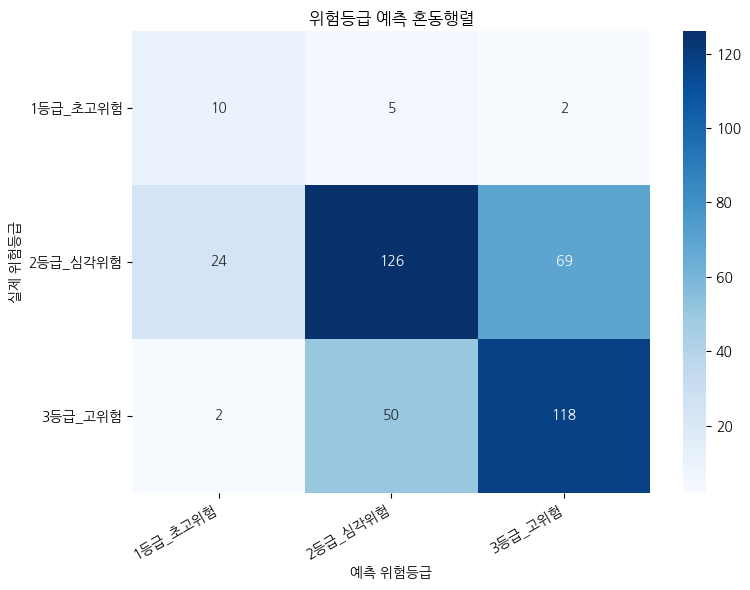

In [ ]:
cm = confusion_matrix(
    y_test,
    pred,
    labels=list(class_name_map.keys())
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[class_name_map[i] for i in class_name_map],
    yticklabels=[class_name_map[i] for i in class_name_map]
)
plt.title('위험등급 예측 혼동행렬')
plt.xlabel('예측 위험등급')
plt.ylabel('실제 위험등급')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. SHAP 계산

다중분류 SHAP은 등급별로 별도의 기여도를 계산합니다.  
기본 해석 대상은 가장 높은 위험등급인 `1등급_초고위험`입니다.


In [ ]:
# 분석할 위험등급 지정
PREFERRED_CLASS = '1등급_초고위험'

if PREFERRED_CLASS in target_encoder.classes_:
    TARGET_CLASS_INDEX = int(target_encoder.transform([PREFERRED_CLASS])[0])
else:
    # 이름이 달라진 경우 위험도 평균이 가장 높은 등급을 자동 선택
    grade_risk_mean = (
        model_df.groupby(TARGET_COL)['위험도_점수']
        .mean()
        .sort_values(ascending=False)
    )
    selected_class_name = grade_risk_mean.index[0]
    TARGET_CLASS_INDEX = int(target_encoder.transform([selected_class_name])[0])
    print(
        f"`{PREFERRED_CLASS}`가 없어 평균 위험도 점수가 가장 높은 "
        f"`{selected_class_name}`을 해석 대상으로 선택했습니다."
    )

TARGET_CLASS_NAME = class_name_map[TARGET_CLASS_INDEX]
print('SHAP 해석 대상:', TARGET_CLASS_NAME)

SHAP_SAMPLE_SIZE = min(3000, len(X_test))
X_shap = X_test.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)
X_shap_raw = X_test_raw.loc[X_shap.index].copy()

explainer = shap.TreeExplainer(model)
raw_shap_values = explainer.shap_values(X_shap)

def select_class_shap(raw_values, class_index, n_samples, n_features):
    """SHAP 버전별 다중분류 반환 형식을 (표본 수, 변수 수)로 통일합니다."""
    if isinstance(raw_values, list):
        return np.asarray(raw_values[class_index])

    arr = np.asarray(raw_values)

    if arr.ndim == 2:
        return arr

    if arr.ndim == 3:
        # (표본, 변수, 클래스)
        if arr.shape[0] == n_samples and arr.shape[1] == n_features:
            return arr[:, :, class_index]
        # (클래스, 표본, 변수)
        if arr.shape[1] == n_samples and arr.shape[2] == n_features:
            return arr[class_index, :, :]

    raise ValueError(f'예상하지 못한 SHAP 배열 형태입니다: {arr.shape}')

shap_values = select_class_shap(
    raw_shap_values,
    TARGET_CLASS_INDEX,
    n_samples=len(X_shap),
    n_features=len(FEATURE_COLS)
)

print('선택된 SHAP 배열 크기:', shap_values.shape)


SHAP 해석 대상: 1등급_초고위험
선택된 SHAP 배열 크기: (406, 3)


## 6. 전체 변수 중요도

평균 절대 SHAP 값이 클수록 해당 변수가 위험등급 예측 전반에 더 큰 영향을 주었다는 뜻입니다.


,변수,평균_절대_SHAP
2,사고형태,1.290912
1,사고장소,1.192509
0,학교급,0.318013


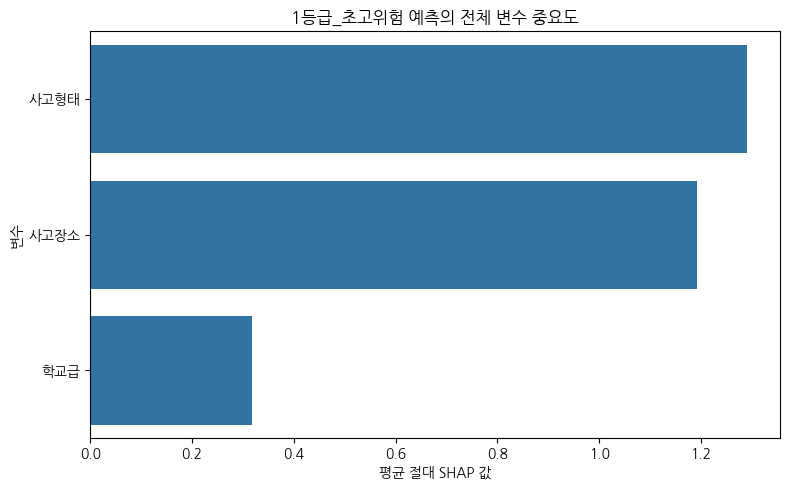

In [ ]:
global_importance = pd.DataFrame({
    '변수': FEATURE_COLS,
    '평균_절대_SHAP': np.abs(shap_values).mean(axis=0)
}).sort_values('평균_절대_SHAP', ascending=False)

display(global_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=global_importance, x='평균_절대_SHAP', y='변수')
plt.title(f'{TARGET_CLASS_NAME} 예측의 전체 변수 중요도')
plt.xlabel('평균 절대 SHAP 값')
plt.ylabel('변수')
plt.tight_layout()
plt.show()


## 7. 실제 범주값별 SHAP 기여도

인코딩된 숫자가 아니라 실제 `학교급`, `사고장소`, `사고형태` 값을 다시 연결해 해석합니다.

- 평균 SHAP 값이 **양수**: 해당 범주가 분석 대상 위험등급 예측을 높이는 방향
- 평균 SHAP 값이 **음수**: 해당 범주가 분석 대상 위험등급 예측을 낮추는 방향
- 평균 절대 SHAP 값이 큼: 방향과 관계없이 모델에 미친 영향이 큼


In [ ]:
shap_df = pd.DataFrame(
    shap_values,
    columns=FEATURE_COLS,
    index=X_shap.index
)

def category_shap_effect(feature, min_count=5, top_n=20):
    if feature not in FEATURE_COLS:
        raise KeyError(f'{feature}는 모델 입력 변수가 아닙니다.')

    temp = pd.DataFrame({
        feature: X_shap_raw[feature].astype(str),
        'SHAP': shap_df[feature]
    })

    result = (
        temp.groupby(feature, dropna=False)
        .agg(
            표본수=('SHAP', 'size'),
            평균_SHAP=('SHAP', 'mean'),
            평균_절대_SHAP=('SHAP', lambda s: np.abs(s).mean())
        )
        .reset_index()
    )

    result = result[result['표본수'] >= min_count]
    return result.sort_values('평균_SHAP', ascending=False).head(top_n)

category_results = {}

for feature in FEATURE_COLS:
    print(f'\n=== {feature}: {TARGET_CLASS_NAME} 예측을 높이는 범주 ===')
    category_results[feature] = category_shap_effect(
        feature,
        min_count=5,
        top_n=20
    )
    display(category_results[feature])



=== 학교급: 1등급_초고위험 예측을 높이는 범주 ===


,학교급,표본수,평균_SHAP,평균_절대_SHAP
0,고등학교,140,0.364497,0.372578
1,중학교,129,-0.039595,0.194182
2,초등학교,137,-0.352696,0.378853



=== 사고장소: 1등급_초고위험 예측을 높이는 범주 ===


,사고장소,표본수,평균_SHAP,평균_절대_SHAP
2,강당(체육관),11,3.125783,3.125783
36,운동장,16,2.840304,2.840304
29,복도,14,2.302540,2.302540
3,계단,5,2.243125,2.243125
37,일반(교과)교실,10,1.676217,1.676217
17,기숙사,8,1.256012,1.256012
7,교통구역(스쿨존 내)-기타 교통구역,5,1.030860,1.030860
33,실·내외 체육시설,16,1.002323,1.002323
21,기타 교외,18,0.938547,0.938547
4,"공원, 유원 시설",8,0.752918,0.752918



=== 사고형태: 1등급_초고위험 예측을 높이는 범주 ===


,사고형태,표본수,평균_SHAP,평균_절대_SHAP
7,그밖의 손상 사고,28,2.048105,2.048105
10,넘어짐,29,2.045862,2.045862
4,고정된 물체와의 부딪힘,29,1.689702,1.689702
0,1미터 미만의 높이에서 떨어짐,13,1.563265,1.563265
5,곤충·식물 등에 쏘임,6,1.033716,1.033716
1,1미터 이상의 높이에서 떨어짐,14,0.734710,0.734710
16,사람과의 부딪힘,20,0.600844,0.612535
17,스포츠 활동 중 충격을 가함,20,0.443597,0.616244
9,기타 호흡 곤란,17,0.170010,0.270805
2,감전,7,-0.136743,0.256862


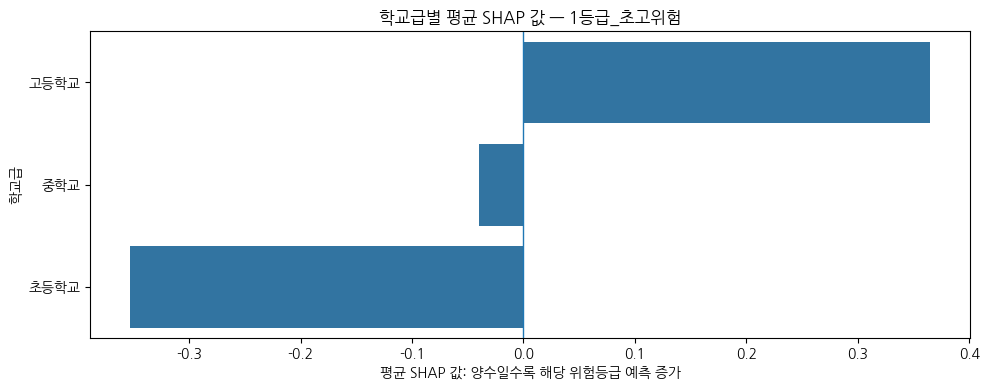

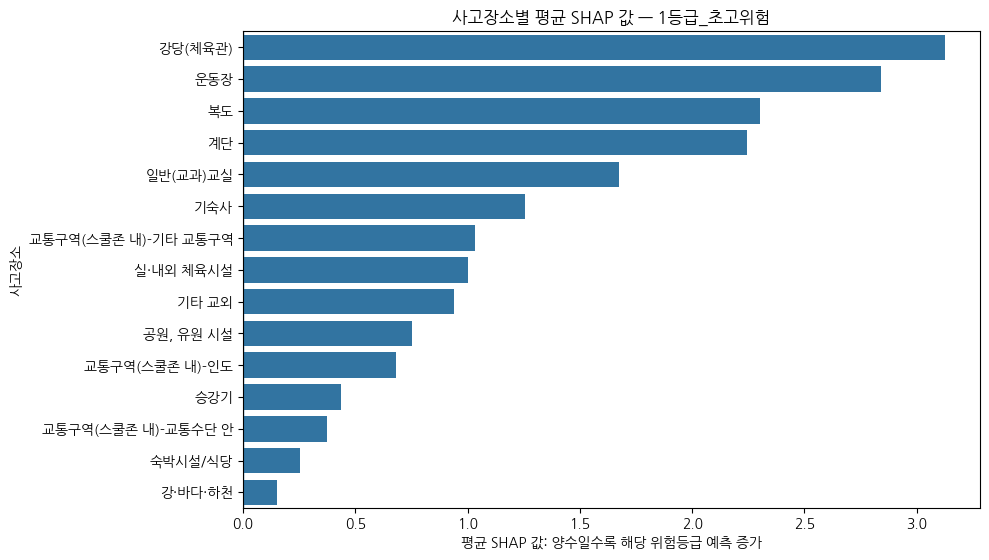

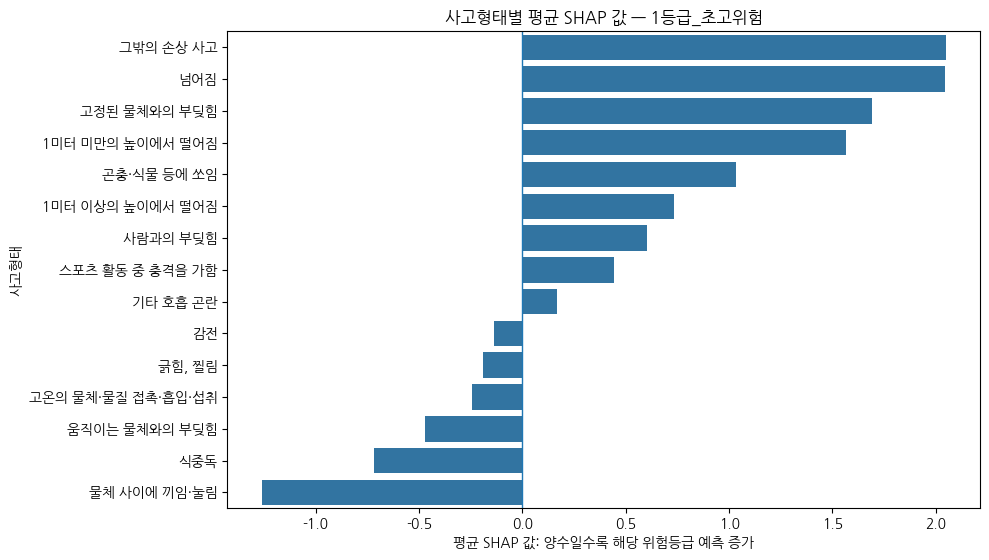

In [ ]:
def plot_category_shap(feature, min_count=5, top_n=15):
    result = category_shap_effect(
        feature,
        min_count=min_count,
        top_n=top_n
    )

    if result.empty:
        print(f'{feature}: 표시 가능한 범주가 없습니다.')
        return

    plt.figure(figsize=(10, max(4, len(result) * 0.38)))
    sns.barplot(
        data=result,
        x='평균_SHAP',
        y=feature
    )
    plt.axvline(0, linewidth=1)
    plt.title(f'{feature}별 평균 SHAP 값 — {TARGET_CLASS_NAME}')
    plt.xlabel('평균 SHAP 값: 양수일수록 해당 위험등급 예측 증가')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

for feature in FEATURE_COLS:
    plot_category_shap(feature)


## 8. 위험도 점수와 SHAP 해석의 일관성 점검

SHAP이 높은 위험등급을 설명하는 방향으로 작동하는지 확인하기 위해,  
모델이 예측한 해당 등급 확률과 기존 `위험도_점수`의 상관관계를 비교합니다.

> 높은 상관관계는 두 결과가 대체로 같은 방향임을 뜻하지만, 인과관계를 증명하지는 않습니다.


Spearman 상관계수: 0.4151


,위험도_점수,1등급_초고위험_예측확률,실제_위험등급
486,6.62,0.958631,1등급_초고위험
1164,6.87,0.951666,1등급_초고위험
1833,4.29,0.949685,1등급_초고위험
1845,3.62,0.843447,2등급_심각위험
1393,4.63,0.833551,1등급_초고위험
20,5.16,0.810724,1등급_초고위험
1069,2.84,0.805775,2등급_심각위험
1172,6.03,0.794472,1등급_초고위험
1186,3.59,0.752747,2등급_심각위험
1161,4.38,0.750708,1등급_초고위험


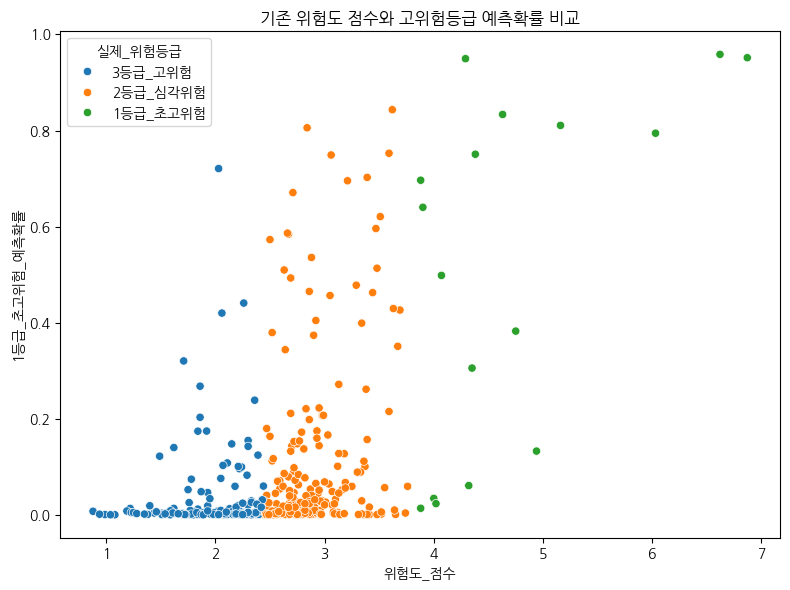

In [ ]:
target_class_proba = pred_proba[:, TARGET_CLASS_INDEX]
test_risk_score = model_df.loc[X_test.index, '위험도_점수']

consistency_df = pd.DataFrame({
    '위험도_점수': test_risk_score,
    f'{TARGET_CLASS_NAME}_예측확률': target_class_proba,
    '실제_위험등급': y_test_raw
})

spearman_corr = consistency_df[
    ['위험도_점수', f'{TARGET_CLASS_NAME}_예측확률']
].corr(method='spearman').iloc[0, 1]

print(f'Spearman 상관계수: {spearman_corr:.4f}')
display(
    consistency_df.sort_values(
        f'{TARGET_CLASS_NAME}_예측확률',
        ascending=False
    ).head(10)
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=consistency_df,
    x='위험도_점수',
    y=f'{TARGET_CLASS_NAME}_예측확률',
    hue='실제_위험등급'
)
plt.title('기존 위험도 점수와 고위험등급 예측확률 비교')
plt.tight_layout()
plt.show()


## 9. 개별 사고유형 해석

분석 대상 위험등급의 예측확률이 가장 높은 사고유형을 선택해,  
학교급·사고장소·사고형태 중 무엇이 예측을 높이거나 낮췄는지 확인합니다.


선택 사례의 1등급_초고위험 예측확률: 0.9586
기존 위험도 점수: 6.62
실제 위험등급: 1등급_초고위험


,학교급,사고장소,사고형태
486,고등학교,운동장,넘어짐


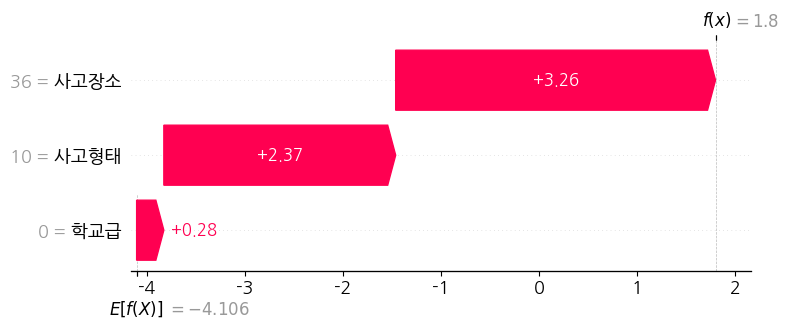

In [ ]:
shap_proba = model.predict_proba(X_shap)[:, TARGET_CLASS_INDEX]
local_position = int(np.argmax(shap_proba))
local_index = X_shap.index[local_position]

print(f'선택 사례의 {TARGET_CLASS_NAME} 예측확률: {shap_proba[local_position]:.4f}')
print('기존 위험도 점수:', model_df.loc[local_index, '위험도_점수'])
print('실제 위험등급:', model_df.loc[local_index, TARGET_COL])

display(X_shap_raw.loc[[local_index]])

expected_value = explainer.expected_value
if isinstance(expected_value, (list, tuple, np.ndarray)):
    base_value = np.asarray(expected_value).reshape(-1)[TARGET_CLASS_INDEX]
else:
    base_value = expected_value

local_explanation = shap.Explanation(
    values=shap_values[local_position],
    base_values=base_value,
    data=X_shap.iloc[local_position].values,
    feature_names=FEATURE_COLS
)

shap.plots.waterfall(local_explanation, max_display=len(FEATURE_COLS))


## 10. SHAP 기반 예방전략 우선순위표

평균 SHAP 값이 양수인 범주 중 영향력이 큰 항목을 추려 예방전략 초안을 만듭니다.  
전략 문구는 자동 제안이므로 실제 학교 현장과 세부 사고 기록을 함께 검토해야 합니다.


In [ ]:
strategy_rules = {
    '사고장소': {
        '운동장': '활동 구역 분리, 충돌 위험 활동 관리, 쉬는시간 순찰 강화',
        '강당': '바닥 미끄럼과 시설물 점검, 종목별 위험구역 표시',
        '체육관': '바닥 상태와 보호장비 점검, 활동 전 안전수칙 안내',
        '계단': '미끄럼 방지 시설 점검, 우측통행 지도, 혼잡시간 관리',
        '복도': '뛰기 방지 지도, 이동 동선 분리, 쉬는시간 순찰 강화',
        '교실': '책상·의자 배치와 모서리 점검, 장난 및 충돌 예방교육',
        '스쿨존': '차량·보행 동선 분리, 등하교 교통안전지도 강화'
    },
    '사고형태': {
        '넘어짐': '미끄럼·장애물 점검, 이동수칙 교육, 준비운동 강화',
        '부딪힘': '활동 공간 확보, 충돌 구역 분리, 과속 이동과 장난 예방',
        '떨어짐': '난간·계단·놀이시설 점검, 높이 활동 감독 강화',
        '물체': '기구 고정과 보관상태 점검, 보호장비 착용 지도',
        '교통': '스쿨존 관리, 차량·보행 동선 분리, 교통안전교육 강화'
    },
    '학교급': {
        '초등학교': '발달단계를 고려한 반복 안전교육과 생활지도 강화',
        '중학교': '체육·쉬는시간의 활동성 높은 사고 예방지도 강화',
        '고등학교': '종목별 체육활동 안전수칙과 시설 점검 강화'
    }
}

def recommend_strategy(feature, category):
    category = str(category)
    default = '해당 사고유형의 원자료를 추가 확인하고 현장 점검과 맞춤형 안전교육을 강화'
    for keyword, strategy in strategy_rules.get(feature, {}).items():
        if keyword in category:
            return strategy
    return default

strategy_rows = []

for feature in FEATURE_COLS:
    result = category_shap_effect(feature, min_count=5, top_n=20)
    result = result[result['평균_SHAP'] > 0].copy()

    for _, row in result.iterrows():
        category = row[feature]
        strategy_rows.append({
            '변수': feature,
            '위험도_상승_범주': category,
            '평균_SHAP': round(float(row['평균_SHAP']), 5),
            '평균_절대_SHAP': round(float(row['평균_절대_SHAP']), 5),
            '표본수': int(row['표본수']),
            '해석': f'{category} 범주는 {TARGET_CLASS_NAME} 예측을 높이는 방향으로 작용',
            '예방전략_초안': recommend_strategy(feature, category)
        })

strategy_table = (
    pd.DataFrame(strategy_rows)
    .sort_values('평균_SHAP', ascending=False)
    .reset_index(drop=True)
)

display(strategy_table.head(30))


,변수,위험도_상승_범주,평균_SHAP,평균_절대_SHAP,표본수,해석,예방전략_초안
0,사고장소,강당(체육관),3.12578,3.12578,11,강당(체육관) 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,"바닥 미끄럼과 시설물 점검, 종목별 위험구역 표시"
1,사고장소,운동장,2.84030,2.84030,16,운동장 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,"활동 구역 분리, 충돌 위험 활동 관리, 쉬는시간 순찰 강화"
2,사고장소,복도,2.30254,2.30254,14,복도 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,"뛰기 방지 지도, 이동 동선 분리, 쉬는시간 순찰 강화"
3,사고장소,계단,2.24312,2.24312,5,계단 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,"미끄럼 방지 시설 점검, 우측통행 지도, 혼잡시간 관리"
4,사고형태,그밖의 손상 사고,2.04810,2.04810,28,그밖의 손상 사고 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,해당 사고유형의 원자료를 추가 확인하고 현장 점검과 맞춤형 안전교육을 강화
5,사고형태,넘어짐,2.04586,2.04586,29,넘어짐 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,"미끄럼·장애물 점검, 이동수칙 교육, 준비운동 강화"
6,사고형태,고정된 물체와의 부딪힘,1.68970,1.68970,29,고정된 물체와의 부딪힘 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,"활동 공간 확보, 충돌 구역 분리, 과속 이동과 장난 예방"
7,사고장소,일반(교과)교실,1.67622,1.67622,10,일반(교과)교실 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,"책상·의자 배치와 모서리 점검, 장난 및 충돌 예방교육"
8,사고형태,1미터 미만의 높이에서 떨어짐,1.56327,1.56327,13,1미터 미만의 높이에서 떨어짐 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,"난간·계단·놀이시설 점검, 높이 활동 감독 강화"
9,사고장소,기숙사,1.25601,1.25601,8,기숙사 범주는 1등급_초고위험 예측을 높이는 방향으로 작용,해당 사고유형의 원자료를 추가 확인하고 현장 점검과 맞춤형 안전교육을 강화


## 11. 분석 결과 저장

In [ ]:
# 1) SHAP 변수 중요도
global_importance.to_csv(
    'shap_global_importance.csv',
    index=False,
    encoding='utf-8-sig'
)

# 2) 범주별 SHAP 결과
category_output = []
for feature, result in category_results.items():
    temp = result.copy()
    temp.insert(0, '변수', feature)
    temp = temp.rename(columns={feature: '범주'})
    category_output.append(temp)

category_output_df = pd.concat(category_output, ignore_index=True)
category_output_df.to_csv(
    'shap_category_effect.csv',
    index=False,
    encoding='utf-8-sig'
)

# 3) 예방전략 우선순위
strategy_table.to_csv(
    'shap_based_prevention_strategy.csv',
    index=False,
    encoding='utf-8-sig'
)

# 4) 평가 데이터의 기존 위험도와 예측확률
consistency_df.to_csv(
    'risk_score_shap_consistency.csv',
    index=True,
    encoding='utf-8-sig'
)

print('저장 완료:')
print('- shap_global_importance.csv')
print('- shap_category_effect.csv')
print('- shap_based_prevention_strategy.csv')
print('- risk_score_shap_consistency.csv')


저장 완료:
- shap_global_importance.csv
- shap_category_effect.csv
- shap_based_prevention_strategy.csv
- risk_score_shap_consistency.csv
